# Credit Risk Analytics Dashboard and Classification Project

## 1. Project Overview
## 2. Import Libraries
## 3. Load Dataset
## 4. Data Overview
## 5. Target Variable Definition
## 6. Feature Decoding
## 7. Exploratory Data Analysis
## 8. Key Business Insights
## 9. Data Preparation for Machine Learning
## 10. Logistic Regression Model
## 11. Random Forest Model
## 12. Model Comparison and Business Cost Evaluation
## 13. Export Outputs
## 14. Final Conclusion

## 1. Import Libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

## 2. Load Dataset

In [56]:
columns = [
    "checking_account_status",
    "duration_month",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_since",
    "installment_rate_pct",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "dependents",
    "telephone",
    "foreign_worker",
    "target"
]

df = pd.read_csv(
    "../data/german.data",
    sep=" ",
    header=None,
    names=columns
)

df.head()

,checking_account_status,duration_month,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


## 3. Data Overview

In [57]:
df.shape


(1000, 21)

In [58]:
df.head()

,checking_account_status,duration_month,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   checking_account_status  1000 non-null   str  
 1   duration_month           1000 non-null   int64
 2   credit_history           1000 non-null   str  
 3   purpose                  1000 non-null   str  
 4   credit_amount            1000 non-null   int64
 5   savings_account          1000 non-null   str  
 6   employment_since         1000 non-null   str  
 7   installment_rate_pct     1000 non-null   int64
 8   personal_status_sex      1000 non-null   str  
 9   other_debtors            1000 non-null   str  
 10  residence_since          1000 non-null   int64
 11  property                 1000 non-null   str  
 12  age                      1000 non-null   int64
 13  other_installment_plans  1000 non-null   str  
 14  housing                  1000 non-null   str  
 15  existing_credits

The dataset contains 1,000 credit applicants and 21 columns, including 20 explanatory variables and one target variable. No missing values were found in the dataset.

## 4. Target Variable Definition

In [60]:
df["default_risk"] = df["target"].map({
    1: 0,
    2: 1
})

df["risk_label"] = df["default_risk"].map({
    0: "Good Credit",
    1: "Bad Credit"
})

df[["target", "default_risk", "risk_label"]].head()

,target,default_risk,risk_label
0,1,0,Good Credit
1,2,1,Bad Credit
2,1,0,Good Credit
3,1,0,Good Credit
4,2,1,Bad Credit


In [61]:
df["risk_label"].value_counts()

risk_label
Good Credit    700
Bad Credit     300
Name: count, dtype: int64

In [62]:
df["risk_label"].value_counts(normalize=True)

risk_label
Good Credit    0.7
Bad Credit     0.3
Name: proportion, dtype: float64

The original target variable uses 1 to represent good credit and 2 to represent bad credit. For modeling purposes, I converted the target into a binary default risk variable, where 0 represents good credit and 1 represents bad credit.

## 5. Feature Decoding

In [63]:
# Decode categorical variables into readable labels

checking_map = {
    "A11": "< 0 DM",
    "A12": "0-200 DM",
    "A13": ">= 200 DM",
    "A14": "No checking account"
}

credit_history_map = {
    "A30": "No credits / paid back duly",
    "A31": "All credits at this bank paid back",
    "A32": "Existing credits paid back duly",
    "A33": "Delay in past payments",
    "A34": "Critical account / other credits"
}

purpose_map = {
    "A40": "New car",
    "A41": "Used car",
    "A42": "Furniture/equipment",
    "A43": "Radio/television",
    "A44": "Domestic appliances",
    "A45": "Repairs",
    "A46": "Education",
    "A47": "Vacation",
    "A48": "Retraining",
    "A49": "Business",
    "A410": "Other"
}

savings_map = {
    "A61": "< 100 DM",
    "A62": "100-500 DM",
    "A63": "500-1000 DM",
    "A64": ">= 1000 DM",
    "A65": "Unknown / no savings"
}

employment_map = {
    "A71": "Unemployed",
    "A72": "< 1 year",
    "A73": "1-4 years",
    "A74": "4-7 years",
    "A75": ">= 7 years"
}

property_map = {
    "A121": "Real estate",
    "A122": "Savings/life insurance",
    "A123": "Car or other",
    "A124": "Unknown / no property"
}

housing_map = {
    "A151": "Rent",
    "A152": "Own",
    "A153": "Free"
}

job_map = {
    "A171": "Unemployed / unskilled non-resident",
    "A172": "Unskilled resident",
    "A173": "Skilled employee",
    "A174": "Management / self-employed"
}

df["checking_account_status"] = df["checking_account_status"].map(checking_map)
df["credit_history"] = df["credit_history"].map(credit_history_map)
df["purpose"] = df["purpose"].map(purpose_map)
df["savings_account"] = df["savings_account"].map(savings_map)
df["employment_since"] = df["employment_since"].map(employment_map)
df["property"] = df["property"].map(property_map)
df["housing"] = df["housing"].map(housing_map)
df["job"] = df["job"].map(job_map)

df.head()

,checking_account_status,duration_month,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target,default_risk,risk_label
0,< 0 DM,6,Critical account / other credits,Radio/television,1169,Unknown / no savings,>= 7 years,4,A93,A101,...,A143,Own,2,Skilled employee,1,A192,A201,1,0,Good Credit
1,0-200 DM,48,Existing credits paid back duly,Radio/television,5951,< 100 DM,1-4 years,2,A92,A101,...,A143,Own,1,Skilled employee,1,A191,A201,2,1,Bad Credit
2,No checking account,12,Critical account / other credits,Education,2096,< 100 DM,4-7 years,2,A93,A101,...,A143,Own,1,Unskilled resident,2,A191,A201,1,0,Good Credit
3,< 0 DM,42,Existing credits paid back duly,Furniture/equipment,7882,< 100 DM,4-7 years,2,A93,A103,...,A143,Free,1,Skilled employee,2,A191,A201,1,0,Good Credit
4,< 0 DM,24,Delay in past payments,New car,4870,< 100 DM,1-4 years,3,A93,A101,...,A143,Free,2,Skilled employee,2,A191,A201,2,1,Bad Credit


## 6. Exploratory Data Analysis

In [64]:
risk_summary = df.groupby("risk_label").agg(
    applicant_count=("default_risk", "count"),
    avg_credit_amount=("credit_amount", "mean"),
    avg_duration_month=("duration_month", "mean"),
    avg_age=("age", "mean"),
    avg_installment_rate=("installment_rate_pct", "mean"),
    avg_existing_credits=("existing_credits", "mean")
)

risk_summary.round(2)

,applicant_count,avg_credit_amount,avg_duration_month,avg_age,avg_installment_rate,avg_existing_credits
risk_label,,,,,,
Bad Credit,300,3938.13,24.86,33.96,3.10,1.37
Good Credit,700,2985.46,19.21,36.22,2.92,1.42


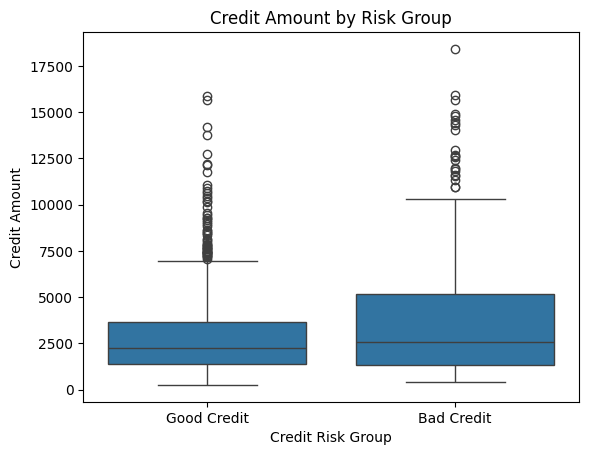

In [65]:
sns.boxplot(data=df, x="risk_label", y="credit_amount")
plt.title("Credit Amount by Risk Group")
plt.xlabel("Credit Risk Group")
plt.ylabel("Credit Amount")
plt.show()

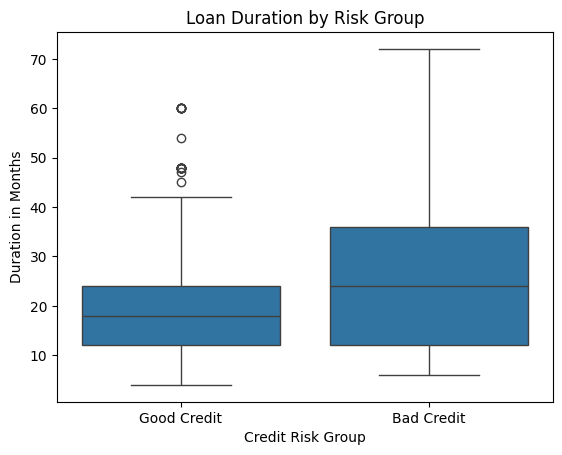

In [66]:
sns.boxplot(data=df, x="risk_label", y="duration_month")
plt.title("Loan Duration by Risk Group")
plt.xlabel("Credit Risk Group")
plt.ylabel("Duration in Months")
plt.show()

In [67]:
checking_risk["default_rate"].plot(kind="bar")

plt.title("Default Rate by Checking Account Status")
plt.xlabel("Checking Account Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

NameError: name 'checking_risk' is not defined

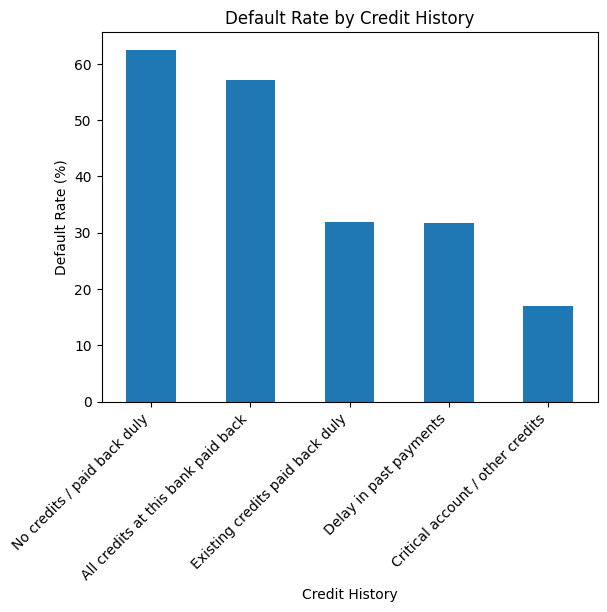

In [ ]:
credit_history_risk["default_rate"].plot(kind="bar")

plt.title("Default Rate by Credit History")
plt.xlabel("Credit History")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

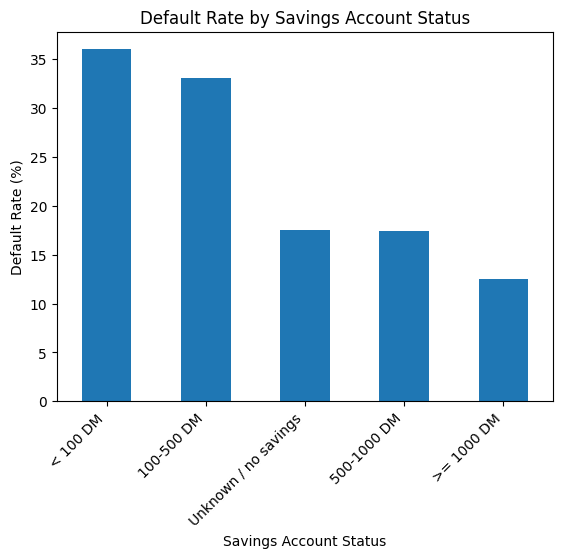

In [ ]:
savings_risk["default_rate"].plot(kind="bar")

plt.title("Default Rate by Savings Account Status")
plt.xlabel("Savings Account Status")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.show()

## 7. Key Business Insights

Bad credit applicants had a higher average credit amount and longer average loan duration than good credit applicants. The average credit amount for bad credit applicants was 3,938.13 DM, compared with 2,985.46 DM for good credit applicants. The average loan duration was also higher for bad credit applicants, at 24.86 months compared with 19.21 months for good credit applicants.

Applicants with negative checking account balances had the highest default rate, which is consistent with financial intuition because negative balances may indicate weak liquidity and short-term cash flow pressure.

Applicants with higher savings account balances generally had lower default rates, suggesting that stronger savings may provide a financial buffer and improve repayment capacity.

Applicants with no prior credit record or limited credit history showed a relatively high default rate. This may suggest that limited credit history makes risk assessment more difficult, even if the applicant has no known negative credit events.

In [ ]:
columns = [
    "checking_account_status",
    "duration_month",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_since",
    "installment_rate_pct",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "dependents",
    "telephone",
    "foreign_worker",
    "target"
]

df = pd.read_csv(
    "../data/german.data",
    sep=" ",
    header=None,
    names=columns
)

df.head()

,checking_account_status,duration_month,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [ ]:
df["default_risk"] = df["target"].map({
    1: 0,
    2: 1
})

df["risk_label"] = df["default_risk"].map({
    0: "Good Credit",
    1: "Bad Credit"
})

df.shape

(1000, 23)

In [ ]:
df[["target", "default_risk", "risk_label"]].head()

,target,default_risk,risk_label
0,1,0,Good Credit
1,2,1,Bad Credit
2,1,0,Good Credit
3,1,0,Good Credit
4,2,1,Bad Credit


## 8. Data Preparation for Machine Learning

The target variable is `default_risk`, where 1 represents bad credit risk and 0 represents good credit. The original target variable and label columns are removed from the feature set to avoid data leakage.

In [ ]:
X = df.drop(columns=["target", "default_risk", "risk_label"])
y = df["default_risk"]

print(X.shape)
print(y.shape)

(1000, 20)
(1000,)


In [ ]:
numeric_features = [
    "duration_month",
    "credit_amount",
    "installment_rate_pct",
    "residence_since",
    "age",
    "existing_credits",
    "dependents"
]

categorical_features = [
    col for col in X.columns if col not in numeric_features
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['duration_month', 'credit_amount', 'installment_rate_pct', 'residence_since', 'age', 'existing_credits', 'dependents']

Categorical features:
['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']


In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (800, 20)
Testing set: (200, 20)


In [ ]:


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## 9. Logistic Regression Model

Logistic Regression was used as the baseline classification model because it is interpretable and commonly used for binary classification problems. Class balancing was applied because the dataset contains more good credit applicants than bad credit applicants.

In [ ]:


log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

log_reg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
y_pred_log = log_reg_model.predict(X_test)
y_prob_log = log_reg_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.75
Precision: 0.5581395348837209
Recall: 0.8
F1 Score: 0.6575342465753424
ROC AUC: 0.8058333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.73      0.80       140
           1       0.56      0.80      0.66        60

    accuracy                           0.75       200
   macro avg       0.73      0.76      0.73       200
weighted avg       0.79      0.75      0.76       200


Confusion Matrix:
[[102  38]
 [ 12  48]]


In [ ]:
cm_log = confusion_matrix(y_test, y_pred_log)

tn, fp, fn, tp = cm_log.ravel()

fp_cost = 1
fn_cost = 5

business_cost_log = fp * fp_cost + fn * fn_cost

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)
print("Business Cost:", business_cost_log)

True Negatives: 102
False Positives: 38
False Negatives: 12
True Positives: 48
Business Cost: 98


## 10. Random Forest Model

A Random Forest model was trained as a comparison model. Random Forest can capture more complex and non-linear patterns in the data, but it may be less directly interpretable than Logistic Regression.

In [ ]:


rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [ ]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

fp_cost = 1
fn_cost = 5

business_cost_rf = fp_rf * fp_cost + fn_rf * fn_cost

print("True Negatives:", tn_rf)
print("False Positives:", fp_rf)
print("False Negatives:", fn_rf)
print("True Positives:", tp_rf)
print("Business Cost:", business_cost_rf)

True Negatives: 109
False Positives: 31
False Negatives: 18
True Positives: 42
Business Cost: 121


## 11. Model Comparison and Business Cost Evaluation

In credit risk analysis, accuracy alone is not sufficient. False negatives are especially costly because they represent bad credit applicants incorrectly classified as good credit applicants. Therefore, model selection also considers recall and a simple business cost framework.

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ],
    "False Positives": [fp, fp_rf],
    "False Negatives": [fn, fn_rf],
    "Business Cost": [business_cost_log, business_cost_rf]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,False Positives,False Negatives,Business Cost
0,Logistic Regression,0.750,0.558,0.8,0.658,0.806,38,12,98
1,Random Forest,0.755,0.575,0.7,0.632,0.800,31,18,121


## Model Selection

Two classification models were compared: Logistic Regression and Random Forest. Although the Random Forest model achieved a slightly higher accuracy of 0.755 compared with 0.750 for Logistic Regression, the Logistic Regression model performed better from a credit risk perspective.

The Logistic Regression model achieved a higher recall of 0.800 for bad credit applicants, compared with 0.700 for Random Forest. This means that Logistic Regression was better at identifying high-risk applicants. In credit risk management, false negatives are especially costly because they represent bad credit applicants incorrectly classified as good credit applicants.

Using a cost-sensitive evaluation where false positives have a cost of 1 and false negatives have a cost of 5, Logistic Regression produced a lower business cost of 98, compared with 121 for Random Forest. Therefore, Logistic Regression was selected as the preferred model for this project.

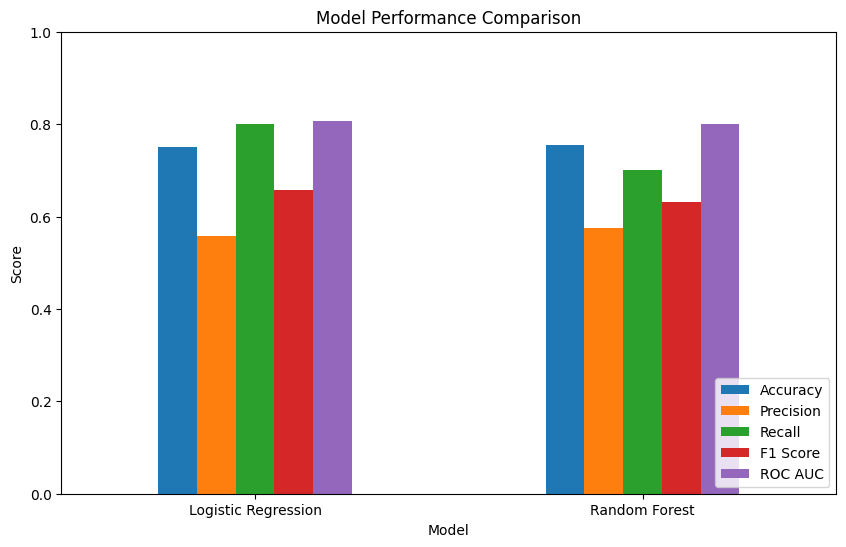

In [ ]:


comparison_plot = model_comparison.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"
]]

comparison_plot.plot(kind="bar", figsize=(10, 6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

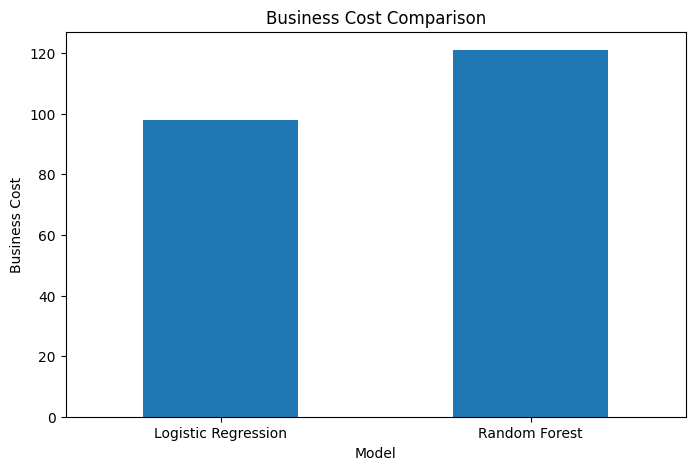

In [ ]:
model_comparison.set_index("Model")["Business Cost"].plot(kind="bar", figsize=(8, 5))

plt.title("Business Cost Comparison")
plt.ylabel("Business Cost")
plt.xticks(rotation=0)
plt.show()

Although the Random Forest model achieved slightly higher accuracy, the Logistic Regression model was preferred because it achieved higher recall for bad credit applicants and a lower business cost.

Logistic Regression achieved a recall of 0.80 and a business cost of 98, while Random Forest achieved a recall of 0.70 and a business cost of 121. Since false negatives are more costly in credit risk management, Logistic Regression better aligns with the business objective of identifying high-risk applicants.

## 12. Export Outputs

The cleaned dataset is exported for Power BI dashboard development. Model predictions are also exported for future analysis.

In [ ]:
predictions = X_test.copy()

predictions["actual_default_risk"] = y_test.values
predictions["log_reg_predicted_risk"] = y_pred_log
predictions["log_reg_default_probability"] = y_prob_log
predictions["rf_predicted_risk"] = y_pred_rf
predictions["rf_default_probability"] = y_prob_rf

predictions.head()

,checking_account_status,duration_month,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors,...,existing_credits,job,dependents,telephone,foreign_worker,actual_default_risk,log_reg_predicted_risk,log_reg_default_probability,rf_predicted_risk,rf_default_probability
30,A12,18,A32,A49,1913,A64,A72,3,A94,A101,...,1,A173,1,A192,A201,0,0,0.406595,0,0.430341
128,A12,12,A34,A41,1860,A61,A71,4,A93,A101,...,2,A174,1,A192,A201,0,0,0.186747,0,0.434439
289,A11,24,A33,A43,1024,A61,A72,4,A94,A101,...,1,A173,1,A191,A201,1,1,0.781344,1,0.639334
216,A11,18,A30,A49,3104,A61,A74,3,A93,A101,...,1,A173,1,A192,A201,0,1,0.715745,1,0.612895
966,A12,27,A34,A43,2520,A63,A73,4,A93,A101,...,2,A172,1,A191,A201,1,0,0.310197,0,0.406727


In [ ]:
predictions.to_csv("../output/model_predictions.csv", index=False)

## 13. Final Conclusion

This project completed an end-to-end credit risk analytics workflow. The analysis identified several important risk patterns, including higher default rates among applicants with negative checking account balances, lower savings balances, larger credit amounts, and longer loan durations.

The Power BI dashboard provides an interactive view of credit risk patterns and portfolio-level indicators such as total applicants, bad credit applicants, default rate, credit amount, and loan duration.

For machine learning, Logistic Regression and Random Forest models were compared. Logistic Regression was selected as the preferred model because it achieved higher recall for bad credit applicants and a lower business cost under the assumed cost-sensitive framework.

Overall, the project demonstrates the use of Python, pandas, scikit-learn, and Power BI to support credit risk analysis, model evaluation, and business-oriented reporting.